# My Brain on TV
## *Does Fatigue Drive What I Watch?*
### Information Visualization · Early Exam · University of Bologna · A.Y. 2025–26

**Author:** Peize Yu  
**Dataset:** `Information_Visualisation_My Brain on TV - CSV.csv`  
**Period:** February – May 2026

---

### Abstract

Over three months, I tracked my every day of TV-watching behaviour — including the days I watched nothing at all. The dataset records not just *what* I watched, but *when*, *how tired I was*, and *what I was doing at the same time*.

This notebook argues a single claim:

> **When I am fatigued, I default to Romance content. When I am rested or focused, I watch Crime/Thriller. Fatigue does not simply increase viewing — it redirects it toward comfort.**

The analysis unfolds in three acts:
1. **Who am I as a viewer?** — establishing the baseline patterns
2. **Does fatigue shape what I watch?** — testing the central claim
3. **What does the data not explain?** — honest limits and critical reflection

---


---
## 0 · Setup


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.15)

# Consistent colour identities throughout the notebook
ROMANCE_COLOR  = "#e07b39"   
CRIME_COLOR    = "#4c78a8"   
NONE_COLOR = "#888888"  
ACCENT        = "#f03b20"           

GENRE_PALETTE = {
    "Romance":       ROMANCE_COLOR,
    "Crime / Thriller": CRIME_COLOR,
    "None":          NONE_COLOR
}

print("Ready.")


Ready.


---
## 1 · Data — Loading, Cleaning & Design Decisions

### Why zero-viewing days are kept

Most personal datasets silently drop days with no activity. I kept them deliberately. A day spent travelling with zero screen time is structurally different from a rest day with five hours of viewing — collapsing both into "missing data" would erase that difference.

> *The absence of viewing is itself a data point.*

### Cleaning rules

| Column | NaN → | Reasoning |
|--------|--------|-----------|
| `Duration_Mins` | `0` | No viewing = zero minutes |
| `Genre` | `'None'` | No content = no genre |
| `Title` | `'None'` | No content watched |
| `Binge_Session` | `False` | Cannot binge without watching |
| `Study_Mins` | `0` | Unrecorded = no study that day |
| `Device` / `Context` | `'None'` | No session = no context |

### A note on Fatigue Level

`Fatigue_Level` is a **self-reported ordinal scale** (1 = Relaxed, 5 = Exhausted), logged at the end of each day.


In [2]:
df_raw = pd.read_csv("Information_Visualisation_My Brain on TV - CSV.csv")

df = df_raw.copy()

# ── Date ──────────────────────────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

# ── Fill zero-viewing days ────────────────────────────────────────────────────
df["Duration_Mins"]  = df["Duration_Mins"].fillna(0).astype(float)
df["Study_Mins"]     = df["Study_Mins"].fillna(0).astype(float)
df["Genre"]          = df["Genre"].fillna("None")
df["Title"]          = df["Title"].fillna("None")
df["Binge_Session"]  = df["Binge_Session"].fillna(False).astype(bool)
df["Device"]         = df["Device"].fillna("None")
df["Context"]        = df["Context"].fillna("None")

# ── Derived columns ───────────────────────────────────────────────────────────
df["Duration_Hrs"]  = df["Duration_Mins"] / 60
df["Is_Zero_Day"]   = df["Duration_Mins"] == 0
df["Month"]         = df["Date"].dt.to_period("M").astype(str)
df["Week"]          = df["Date"].dt.isocalendar().week.astype("Int64")
df["DayOfWeek"]     = df["Date"].dt.day_name()
df["DayOfWeek_N"]   = df["Date"].dt.dayofweek

# Fatigue as string for categorical plots
fatigue_labels = {1: "1-Relaxed", 2: "2-Fine", 3: "3-Tired",
                  4: "4-Drained", 5: "5-Exhausted"}
df["Fatigue_Label"] = df["Fatigue_Level"].map(fatigue_labels)

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"Rows: {len(df)}  |  Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Zero-viewing days : {df['Is_Zero_Day'].sum()} ({df['Is_Zero_Day'].mean()*100:.1f}%)")
print(f"Total viewing     : {df['Duration_Hrs'].sum():.1f} hrs")
print(f"Genres present    : {sorted(df['Genre'].unique())}")


Rows: 88  |  Date range: 2026-02-17 → 2026-05-15
Zero-viewing days : 9 (10.2%)
Total viewing     : 200.0 hrs
Genres present    : ['Crime / Thriller', 'None', 'Romance']


---
## Act I — Who Am I as a Viewer?

Before testing the central claim, we need to establish the baseline: what does my viewing look like overall, and what patterns exist across day types and time?

---

### Chart 1 · Genre Distribution Across Day Types

**Graphical choices:**
- *Normalised stacked bar chart* — we care about genre *proportion* within each day type, not absolute minutes. A raw bar chart would mislead because Rest days have far more total viewing than Travel days.
- *Colour identity* — orange = Romance, blue = Crime/Thriller, grey = None (zero-viewing days). These colours are used consistently throughout the notebook.


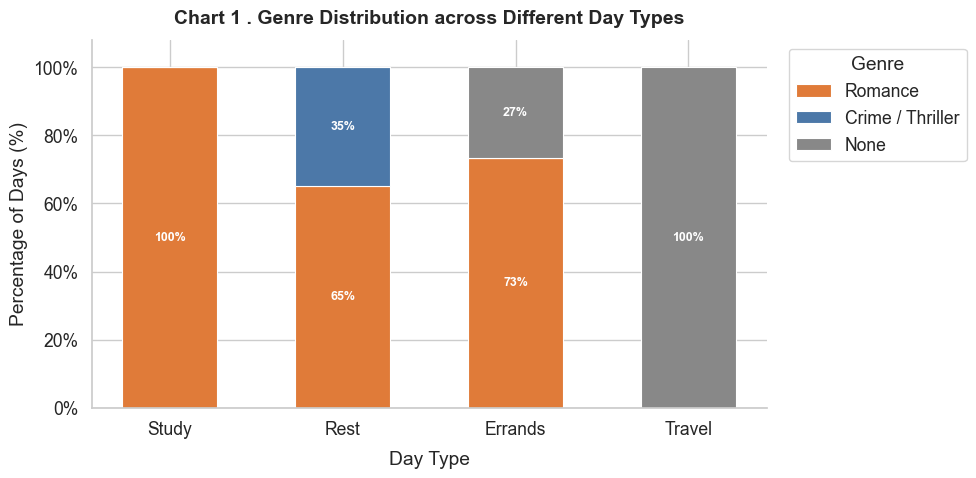

In [95]:
fig, ax = plt.subplots(figsize=(10, 5))

day_order = ["Study", "Rest", "Errands", "Travel"]
genres = ["Romance", "Crime / Thriller", "None"]

# ── Build percentages counting days, not minutes ──────────────────────────────
# Use number of days per genre per day_type so zero-viewing days count as "None"
genre_day_counts = (
    df.groupby(["Day_Type", "Genre"])
    .size()
    .reset_index(name="Count")
)

rows = []
for day in day_order:
    sub = genre_day_counts[genre_day_counts["Day_Type"] == day]
    total = sub["Count"].sum()
    row = {}
    for g in genres:
        count = sub[sub["Genre"] == g]["Count"].sum()
        row[g] = (count / total * 100) if total > 0 else 0
    if total == 0:
        row["None"] = 100
    rows.append(row)

pct_df = pd.DataFrame(rows, index=day_order)

# ── Plot ──────────────────────────────────────────────────────────────────────
bottom = [0] * len(day_order)
genre_colors = {
    "Romance":          "#e07b39",
    "Crime / Thriller": "#4c78a8",
    "None":             "#888888"
}

for genre in genres:
    values = pct_df[genre].values if genre in pct_df.columns else [0]*len(day_order)
    ax.bar(day_order, values, bottom=bottom,
           color=genre_colors[genre],
           label=genre, width=0.55,
           edgecolor="white", linewidth=0.8)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val > 8:
            ax.text(i, bot + val/2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title("Chart 1 . Genre Distribution across Different Day Types",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Day Type", labelpad=8)
ax.set_ylabel("Percentage of Days (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 108)
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart1_genre_daytype.png", dpi=150, bbox_inches="tight")
plt.show()

**What we see:**
Romance dominates on Study and Errands days — the two day types associated with cognitive load and time pressure. On Rest days, Crime/Thriller has a notably higher share, suggesting that when I have time and mental space, I choose more demanding content. Travel days only contain zero-viewing (grey) sessions due to the extreme physical fatigue.

**Why it matters:**
The chart already hints at the central argument: genre choice is not random. It varies systematically with day type — and day type is a proxy for cognitive state.


---
### Chart 2 · Calendar Heatmap — The Rhythm of Viewing Over Time

**Graphical choices:**
- *Interative Calendar heatmap* — An overview of my TV viewing actions during the data collection period, the spatial layout mirrors real calendar time with X-axis maps macro-progression (academic weeks) and Y-axis groups data by micro-cycles (days of the week), making clusters and gaps immediately visible without reading any numbers. 
- Binge sessions are marked with a blue coloured border rather than a separate chart, keeping temporal context intact. As for the hours watching color bar, the transition from yellow to orange indicates the linear sequence of time increase. Crucially, zero-viewing days are strictly preserved and encoded as neutral grey to represent specific context.
- To prevent visual clutter and reduce cognitive load, TV viewing details are abstracted into interactive tooltips.


In [105]:
# ----------------------------------------------------------------------------
# 1. 数据聚合：提取所有情境维度 (Study, Fatigue, Day Type, Device)
# ----------------------------------------------------------------------------
if "Duration_Hrs" not in df.columns:
    df["Duration_Hrs"] = df["Duration_Mins"] / 60.0

daily_agg = df.groupby("Date").agg(
    Duration_Hrs=("Duration_Hrs", "sum"),
    Binge=("Binge_Session", "any"),
    Genres=("Genre", lambda x: ", ".join(x.dropna().unique())),
    Titles=("Title", lambda x: ", ".join(x.dropna().unique())),
    Regions=("Region", lambda x: ", ".join(x.dropna().unique())),
    # 👇 新增提取 4 个全新维度
    Study_Mins=("Study_Mins", "sum"), 
    Fatigue=("Fatigue_Level", lambda x: ", ".join(x.dropna().astype(int).astype(str).unique())),
    Day_Types=("Day_Type", lambda x: ", ".join(x.dropna().unique())),
    Devices=("Device", lambda x: ", ".join(x.dropna().unique()))
).copy()

date_range = pd.date_range(daily_agg.index.min(), daily_agg.index.max())
df_grid = daily_agg.reindex(date_range)

# ----------------------------------------------------------------------------
# 2. 空缺数据（零观影日）的安全填充
# ----------------------------------------------------------------------------
df_grid["Duration_Hrs"] = df_grid["Duration_Hrs"].fillna(0).astype(float)
df_grid["Binge"] = df_grid["Binge"].fillna(False).astype(bool)
df_grid["Genres"] = df_grid["Genres"].replace("", "None").fillna("None").astype(str)
df_grid["Titles"] = df_grid["Titles"].replace("", "None").fillna("None").astype(str)
df_grid["Regions"] = df_grid["Regions"].replace("", "None").fillna("None").astype(str)

# 👇 新增列的填充逻辑
df_grid["Study_Mins"] = df_grid["Study_Mins"].fillna(0).astype(int).astype(str)
df_grid["Fatigue"] = df_grid["Fatigue"].replace("", "N/A").fillna("N/A").astype(str)
df_grid["Day_Types"] = df_grid["Day_Types"].replace("", "None").fillna("None").astype(str)
df_grid["Devices"] = df_grid["Devices"].replace("", "None").fillna("None").astype(str)

start_monday = df_grid.index.min() - pd.Timedelta(days=df_grid.index.min().dayofweek)
df_grid['X_Num'] = (df_grid.index - start_monday).days // 7
df_grid['Y_Num'] = 6 - df_grid.index.dayofweek

weekdays_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df_grid['Weekday_Name'] = df_grid.index.dayofweek.map(weekdays_map)
df_grid['Date_Str'] = df_grid.index.strftime('%Y-%m-%d')

# ----------------------------------------------------------------------------
# 3. 悬停提示拼接：打造终极全景信息流
# ----------------------------------------------------------------------------
binge_labels = np.where(df_grid['Binge'], 'Yes', 'No')
durations = df_grid['Duration_Hrs'].round(1).astype(str)

df_grid['Hover_Text'] = (
    "<b>📅 Date:</b> " + df_grid['Date_Str'] + " (" + df_grid['Weekday_Name'] + ")<br>" +
    "<b>🗓️ Day Type:</b> " + df_grid['Day_Types'] + "<br>" +
    "<b>📚 Study:</b> " + df_grid['Study_Mins'] + " mins<br>" +
    "<b>🔋 Fatigue:</b> Level " + df_grid['Fatigue'] + "<br>" +
    "────────────────────<br>" +  # 用一条分割线区分“生活情境”和“观影细节”
    "<b>⏱️ Watched:</b> " + durations + " hrs<br>" +
    "<b>🚨 Binge:</b> " + binge_labels + "<br>" +
    "<b>📺 Title:</b> " + df_grid['Titles'] + "<br>" +
    "<b>🎬 Genre:</b> " + df_grid['Genres'] + "<br>" +
    "<b>🌍 Region:</b> " + df_grid['Regions'] + "<br>" +
    "<b>📱 Device:</b> " + df_grid['Devices']
)

weeks_range = sorted(df_grid['X_Num'].unique())
plot_order = ["Sun", "Sat", "Fri", "Thu", "Wed", "Tue", "Mon"]

z_matrix = df_grid.pivot(index='Weekday_Name', columns='X_Num', values='Duration_Hrs')
z_matrix = z_matrix.reindex(index=plot_order, columns=weeks_range).fillna(0)

text_matrix = df_grid.pivot(index='Weekday_Name', columns='X_Num', values='Hover_Text')
text_matrix = text_matrix.reindex(index=plot_order, columns=weeks_range).fillna("")

# ----------------------------------------------------------------------------
# 4. 图表渲染 (保留了你全部的格式设定)
# ----------------------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Heatmap(
    x=weeks_range,
    y=[0, 1, 2, 3, 4, 5, 6], 
    z=z_matrix.values,
    customdata=text_matrix.values,
    hovertemplate="%{customdata}<extra></extra>",
    colorscale=[
        [0.0, '#f5f5f5'],
        [0.01, '#ffeda0'],  
        [0.5, '#feb24c'],   
        [1.0, '#f03b20']    
    ],
    zmin=0,
    zmax=4,
    showscale=True,
    xgap=4, 
    ygap=4,
    colorbar=dict(
        thickness=15, 
        len=0.8, 
        x=0.8,
        xpad=5
    )
))

binge_days = df_grid[df_grid['Binge'] == True]
fig.add_trace(go.Scatter(
    x=binge_days['X_Num'],
    y=binge_days['Y_Num'],
    mode='markers',
    marker=dict(
        symbol='square-open',
        size=30,              
        color='#4C72B0',      
        line=dict(width=3)
    ),
    name="Binge Session",
    hoverinfo="skip"
))

tick_vals = list(range(0, len(weeks_range), 2))
tick_text = [f"W{i+1}" for i in tick_vals]

fig.update_layout(
    title=dict(
        text="<b>Chart 2 · Calendar Heatmap — The Rhythm of Viewing Over Time</b><br><sup>Grid layout. Grey cells represent 'Zero-Viewing Days'. Blue borders highlight Binge Sessions.</sup>",
        font=dict(size=16),
        x=0.02
    ),
        font=dict(
        family="Arial, Helvetica, sans-serif",
        color="#2c3e50",
        size=12
    ),
    annotations=[
        dict(
            x=0.85,          
            y=1.07,           
            xref="paper", 
            yref="paper",
            text="Hours<br>Watched",
            showarrow=False,  
            align="left",
            font=dict(size=12) 
        )
    ],
    xaxis=dict(
        title="Weeks",
        tickmode='array',
        tickvals=tick_vals,
        ticktext=tick_text,
        showgrid=False,
        zeroline=False,
        fixedrange=True,
        constrain='domain'
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3, 4, 5, 6],
        ticktext=["Sun", "Sat", "Fri", "Thu", "Wed", "Tue", "Mon"],
        scaleanchor="x",    
        scaleratio=1,
        showgrid=False,
        zeroline=False,
        fixedrange=True,
        constrain='domain'
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1150,  
    height=380,  
    margin=dict(t=80, b=30, l=50, r=20),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.08,             
        xanchor="left",
        x=0.77,              
        font=dict(size=11)
    )
)

fig.show()

**What we see:**
Viewing is not evenly distributed. There are visible clusters of high-intensity days (deep orange) separated by grey stretches of non-viewing. Binge sessions do not appear randomly — they tend to follow grey periods, they appear repetitively on weekends, during Week 9 to Week 11 they also appear repetitively on Monday and Thursday (these are days with high study intensity), this is consistent with a pattern of deferred viewing after high-workload stretches.

**Why it matters:**
The calendar makes the *structure* of my viewing visible in a way that summary statistics cannot. It sets up the next question: what was happening on those high-intensity days?


---
## Act II — Does Fatigue Shape What I Watch?

This is the core of the analysis. Three charts build the argument progressively: first establishing that fatigue affects *how much* I watch, then that it affects *what* I watch, then that it shapes *how* I watch it.

---

### Chart 3 · Fatigue Level vs. Viewing Duration

**Graphical choices:**
- *Box plot* — shows median, spread and outliers simultaneously. Preferred over a bar chart of means because the *distribution shape* (not just the average) is the finding here.
- *Fatigue as ordinal x-axis* — preserves rank order without implying equal intervals between levels. Using a sequential color trastion from pale yellow to dark red acts also as visual metaphor for the expression of fatigue level.
- Instead of forcing the reader to hunt for insights, the chart employs direct labeling (explicit mean values `μ=...` floating above the whiskers) and an explanatory text box with an arrow pointing directly to the Level 5 outliers. This technique reduces the reader's cognitive load and instantly anchors their attention to the core narrative of the chart.

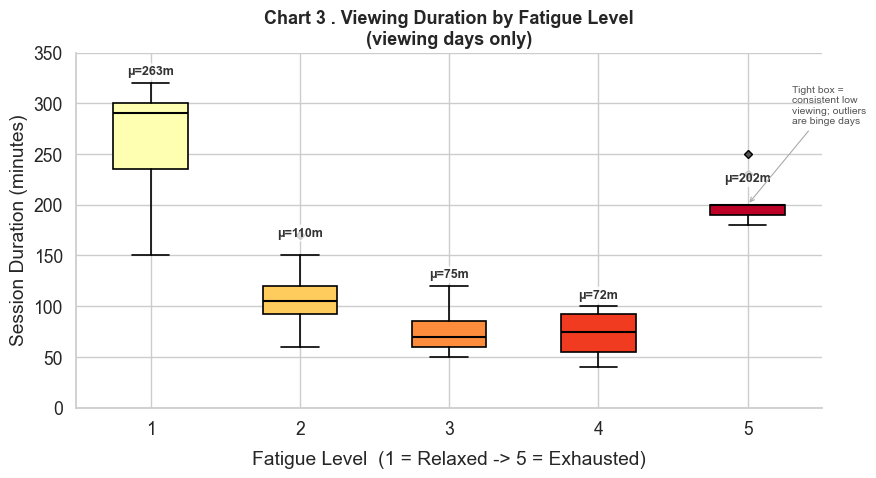

In [96]:
fatigue_order_int = [1, 2, 3, 4, 5]
fatigue_order_str = [str(i) for i in fatigue_order_int]
fatigue_colors_list = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
fatigue_palette = dict(zip(fatigue_order_str, fatigue_colors_list))

plot_data = df[df["Duration_Mins"] > 0].copy()
plot_data["Fatigue_Str"] = plot_data["Fatigue_Level"].astype(str)

fig, ax = plt.subplots(figsize=(9, 5))

# Draw each box manually with its own color
for i, (fl, color) in enumerate(zip(fatigue_order_int, fatigue_colors_list)):
    sub = plot_data[plot_data["Fatigue_Level"] == fl]["Duration_Mins"]
    if len(sub) > 0:
        bp = ax.boxplot(sub, positions=[i], widths=0.5,
                        patch_artist=True,
                        flierprops=dict(marker="D", markerfacecolor="#555",
                                        markersize=4, linestyle="none"),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, linewidth=1.2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2))

# Mean annotations
for i, fl in enumerate(fatigue_order_int):
    sub = plot_data[plot_data["Fatigue_Level"] == fl]["Duration_Mins"]
    if len(sub) > 0:
        # Place label above the maximum whisker (not the mean)
        whisker_top = sub.quantile(0.75) + 1.5 * (sub.quantile(0.75) - sub.quantile(0.25))
        whisker_top = min(whisker_top, sub.max())  # cap at actual max
        ax.text(i, whisker_top + 8, f"μ={sub.mean():.0f}m",
                ha="center", fontsize=9, color="#333", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="none", alpha=0.8))

ax.set_xticks(range(len(fatigue_order_int)))
ax.set_xticklabels(fatigue_order_int)
ax.set_title("Chart 3 . Viewing Duration by Fatigue Level\n(viewing days only)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Fatigue Level  (1 = Relaxed -> 5 = Exhausted)", labelpad=8)
ax.set_ylabel("Session Duration (minutes)")
ax.set_ylim(0, plot_data["Duration_Mins"].max() + 30)
ax.spines[["top","right"]].set_visible(False)

# Annotate Level 5 explanation
ax.annotate("Tight box =\nconsistent low\nviewing; outliers\nare binge days",
            xy=(4, 200), xytext=(4.3, 280),
            fontsize=7.5, color="#555",
            arrowprops=dict(arrowstyle="->", color="#aaa", lw=0.8))

plt.tight_layout()
plt.savefig("chart3_fatigue_duration.png", dpi=150, bbox_inches="tight")
plt.show()


**What we see:**
The relationship between fatigue and duration is **U-shaped**, not linear. The longest sessions occur at Level 1 (Relaxed) and Level 5 (Exhausted) — but for structurally different reasons. At Level 1, sessions are long and deliberate (chosen leisure). At Level 5 (Exhausted), the box itself remains very tight—meaning *most* days feature very low viewing times. However, this level produces extreme upper outliers (the dark grey diamonds extending past 200 minutes). This reveals a "compensatory bingeing" effect: on days of absolute exhaustion, the normal constraints occasionally snap, resulting in massive, revenge-viewing sessions. At moderate fatigue (Levels 2–4), sessions are shorter and more consistent.

**Why it matters:**
Fatigue does not simply *increase* or *decrease* viewing — it changes its *character*. This sets up the key question: does it also change genre?


---
### Chart 4 · Genre Share by Fatigue Level — The Central Finding

**Graphical choices:**
- *Normalised stacked bar chart* — same rationale as Chart 1. Proportion is the variable of interest, not absolute minutes, because different fatigue levels have different numbers of days.
- *Consistent genre colours* — orange/blue identity maintained so the reader does not have to re-learn the legend.
- Zero-viewing days (grey) are included to show non-engagement as part of the fatigue story.


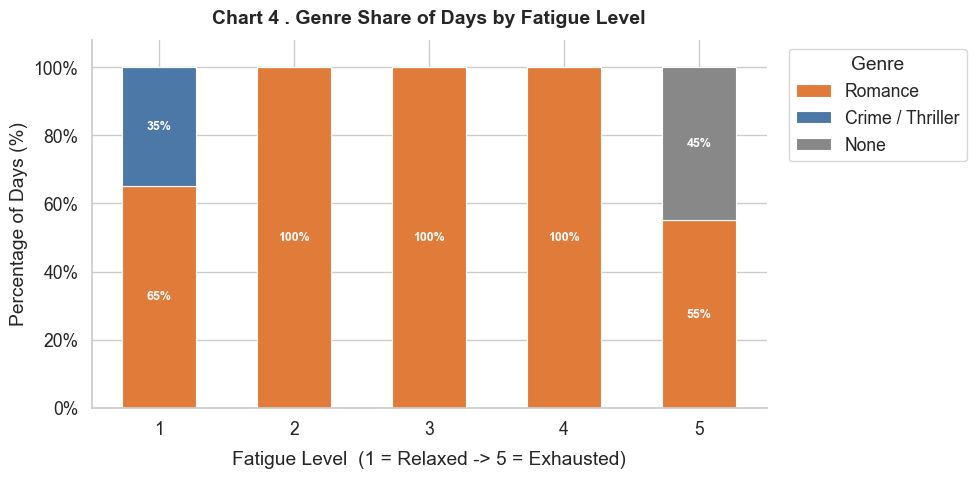

In [97]:
fatigue_order_int = [1, 2, 3, 4, 5]
genres = ["Romance", "Crime / Thriller", "None"]
genre_colors = {
    "Romance":          "#e07b39",
    "Crime / Thriller": "#4c78a8",
    "None":             "#888888"
}

# ── Count days per fatigue level per genre ────────────────────────────────────
genre_fatigue_counts = (
    df.groupby(["Fatigue_Level", "Genre"])
    .size()
    .reset_index(name="Count")
)

rows = []
for fl in fatigue_order_int:
    sub = genre_fatigue_counts[genre_fatigue_counts["Fatigue_Level"] == fl]
    total = sub["Count"].sum()
    row = {}
    for g in genres:
        count = sub[sub["Genre"] == g]["Count"].sum()
        row[g] = (count / total * 100) if total > 0 else 0
    if total == 0:
        row["None"] = 100
    rows.append(row)

pct_df = pd.DataFrame(rows, index=fatigue_order_int)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bottom = [0] * len(fatigue_order_int)

for genre in genres:
    values = pct_df[genre].values if genre in pct_df.columns else [0]*len(fatigue_order_int)
    ax.bar(fatigue_order_int, values, bottom=bottom,
           color=genre_colors[genre],
           label=genre, width=0.55,
           edgecolor="white", linewidth=0.8)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val > 8:
            ax.text(fatigue_order_int[i], bot + val/2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title("Chart 4 . Genre Share of Days by Fatigue Level",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Fatigue Level  (1 = Relaxed -> 5 = Exhausted)", labelpad=8)
ax.set_ylabel("Percentage of Days (%)")
ax.set_xticks(fatigue_order_int)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 108)
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart4_genre_fatigue.png", dpi=150, bbox_inches="tight")
plt.show()

**What we see:**
The central claim holds. Romance share **rises with fatigue**. Crime/Thriller, conversely, is concentrated only on the lowest fatigue level — Level 1 (Relaxed), where cognitive bandwidth is available for a more demanding narrative. At Level 5, the grey (None) segment is notable — complete exhaustion sometimes produces non-engagement rather than viewing.

**Why it matters:**
This is the strongest evidence in the dataset for the central argument. Genre choice is not random noise — it tracks a measurable internal state. The chart transforms a subjective feeling ("I watch comfort TV when I'm tired") into a visible, structured pattern.


---
### Chart 5 · Viewing Context × Genre — How I Watch Reflects What I Watch

**Graphical choices:**
- *Heatmap with count annotations* — shows frequency of each Context/Genre combination simultaneously. A grouped bar chart would work but the heatmap makes the asymmetry (high Romance × Eating cell) immediately visible through colour saturation.
- *Sequential colour scale* — encodes quantity (more = darker), appropriate for this ratio variable.


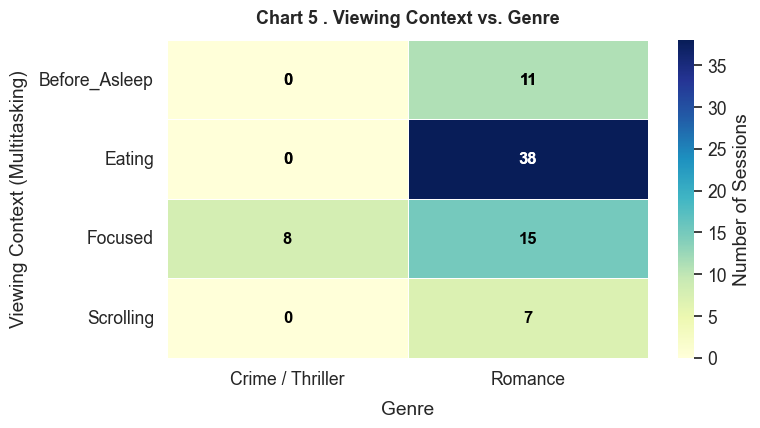

In [98]:
ctx_genre = (
    df[(df["Context"] != "None") & (df["Genre"] != "None")]
    .groupby(["Context", "Genre"])
    .size()
    .reset_index(name="Count")
)

present_genres_ctx = [g for g in ["Crime / Thriller", "Romance"]
                      if g in ctx_genre["Genre"].unique()]

pivot_ctx = (ctx_genre
             .pivot(index="Context", columns="Genre", values="Count")
             .fillna(0)
             [present_genres_ctx])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    pivot_ctx, annot=True, fmt=".0f",
    cmap="YlGnBu", linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Number of Sessions"},
    annot_kws={"size": 12, "weight": "bold"},
    vmin=0  # ← force scale to start at 0 so small values still get colour
)

# Override annotations manually so ALL cells show numbers
for i in range(pivot_ctx.shape[0]):
    for j in range(pivot_ctx.shape[1]):
        val = int(pivot_ctx.iloc[i, j])
        # Choose text colour based on cell brightness
        text_color = "white" if val > 20 else "black"
        ax.text(j + 0.5, i + 0.5, str(val),
                ha="center", va="center",
                fontsize=12, fontweight="bold", color=text_color)

ax.set_title("Chart 5 . Viewing Context vs. Genre",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Genre", labelpad=8)
ax.set_ylabel("Viewing Context (Multitasking)", labelpad=8)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("chart5_context_genre.png", dpi=150, bbox_inches="tight")
plt.show()

**What we see:**
The heatmap reveals a clear asymmetry. Romance is overwhelmingly associated with distracted contexts — eating, scrolling, before falling asleep. Crime/Thriller sessions are concentrated under "Focused" — the only context requiring sustained attention. There are virtually zero Crime/Thriller sessions while eating, scrolling or before_asleep.

**Why it matters:**
This adds a qualitative dimension to the fatigue argument. Fatigue does not just redirect genre choice — it changes the *mode* of watching. Comfort content is consumed passively, in parallel with other low-effort activities. This is consistent with using TV as background regulation or comforting content rather than active entertainment.


---
### Chart 6 · Study Load vs. Viewing Duration — TV as Decompression

**Graphical choices:**
- *Interactive Scatter plot* — A scatter plot is the optimal channel to visualize the relationship between two continuous quantitative variables (Study Minutes and Viewing Minutes). 
- *Third-Variable Encoding via Color (Fatigue)* — To understand *why* the data deviates from a simple negative correlation, a third ordinal variable (Fatigue Level) is encoded using a diverging-like continuous color scale. The warm/red colors act as visual alarms for high cognitive load, while the green hints rather relaxed mood, adding explanatory depth to the spatial coordinates.
- *Semantic Tooltips for Narrative Grounding* — The interactive tooltip connects abstract dots back to lived reality. Hovering reveals not just the numbers, but the specific *Date, Title, and Genre*, bridging the gap between quantitative metrics and qualitative behavioral context.


In [106]:

# 1. 过滤并准备数据
scatter_data = df[(df["Study_Mins"] > 0) | (df["Duration_Mins"] > 0)].copy()

# 为了让 Tooltip 更具可读性，格式化日期格式并处理空值
scatter_data['Date_Str'] = scatter_data['Date'].dt.strftime('%b %d')
scatter_data['Title'] = scatter_data['Title'].replace("None", "Unknown").fillna("Unknown")
scatter_data['Genre'] = scatter_data['Genre'].fillna("None")

# 2. 🚀 核心修复 1：引入视觉抖动 (Jitter) 打破重叠
np.random.seed(42) # 固定随机种子，保证每次画出来的图长得一样
# 在实际坐标上微调 ±4 分钟，足以让重叠的点散开，又不影响宏观趋势
scatter_data['Plot_Study'] = scatter_data['Study_Mins'] + np.random.uniform(-4, 4, size=len(scatter_data))
scatter_data['Plot_Duration'] = scatter_data['Duration_Mins'] + np.random.uniform(-4, 4, size=len(scatter_data))

# 3. 🚀 核心修复 2：悬停文本依然焊死【真实数据】，不受抖动影响
scatter_data['Hover_HTML'] = (
    "<b>📅 " + scatter_data['Date_Str'] + "</b><br>" +
    "📺 Show: <b>" + scatter_data['Title'] + "</b><br>" +
    "🎬 Genre: " + scatter_data['Genre'] + "<br>" +
    "🚨 Fatigue: Level " + scatter_data['Fatigue_Level'].astype(int).astype(str) + "<br>" +
    "⏱️ Study: " + scatter_data['Study_Mins'].astype(int).astype(str) + " mins<br>" +  # <--- 真实学习时间
    "📺 Watched: " + scatter_data['Duration_Mins'].astype(int).astype(str) + " mins"   # <--- 真实观看时间
)

# 4. 绘制交互式散点图 (X和Y使用抖动后的坐标)
fig = px.scatter(
    scatter_data,
    x="Plot_Study",      # <--- 使用加了抖动的坐标画图
    y="Plot_Duration",   # <--- 使用加了抖动的坐标画图
    color="Fatigue_Level",
    color_continuous_scale="RdYlGn_r",
    range_color=[1, 5],
    custom_data=["Hover_HTML"] 
)

# 5. 定制气泡样式
fig.update_traces(
    marker=dict(size=12, line=dict(width=1, color='white'), opacity=0.82), # 透明度调到0.82，重叠的边缘更好看
    hovertemplate="%{customdata[0]}<extra></extra>"  
)

# 6. 布局与色条复刻 (隐藏抖动轴的名字，显示真实名字)
fig.update_layout(
    title=dict(
        text="<b>Chart 6 · Study Minutes vs. Viewing Minutes per Day</b><br><sup>Colour = Fatigue Level. A slight jitter is applied to prevent overplotting.</sup>",
        font=dict(size=16)
    ),
    font=dict(
        family="Arial, Helvetica, sans-serif",
        color="#2c3e50",
        size=12
    ),
    xaxis=dict(
        title=dict(text="Study Duration (minutes)", standoff=15),
        showgrid=True, 
        gridcolor="#f0f0f0", 
        zeroline=True, 
        zerolinecolor="#dcdcdc"
    ),
    yaxis=dict(
        title=dict(text="Viewing Duration (minutes)", standoff=15),
        showgrid=True, 
        gridcolor="#f0f0f0", 
        zeroline=True, 
        zerolinecolor="#dcdcdc"
    ),
    coloraxis_colorbar=dict(
        title="<b>Fatigue Level</b><br>&nbsp;",  
        tickvals=[1, 2, 3, 4, 5],
        ticktext=["1  Relaxed", "2", "3", "4", "5  Exhausted"],
        thickness=15,
        len=0.75,
        outlinewidth=0
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=900,
    height=550,
    margin=dict(t=90, b=50, l=65, r=20)
)

fig.show()

**What we see:**
The scatter plot does not show a simple displacement effect (more study = less TV). Instead, Romance viewing is distributed *across all study levels* — including high-study days. Pay attention to the points pushed towards the upper-right (e.g., studying >250 mins AND watching >150 mins). Notice their color: they are almost exclusively red (Fatigue Level 5). This reveals a profound insight: my longer viewing sessions on heavy study days are driven by extreme fatigue. I do not simply "watch TV when I have free time"; I watch TV regardless of academic load. 

**Why it matters:**
This complicates the central claim in a productive way. Fatigue-driven comfort viewing is not simply filling time left over from studying — it appears to be a parallel coping mechanism, present even on busy days. The TV is being used as a high-dosage cognitive painkiller. TV is decompression, not just leisure.


---
## Act III — What Does the Data Not Explain?

### Critical Disclosure

The six charts above build a coherent argument: fatigue redirects viewing toward comfort genre, consumed passively, regardless of study load. But a dataset is not a proof. Following the core tenets of information visualization ethics, we must interrogate the process of translating human experience into structured data, and acknowledge the absolute limits of the visual medium.

---

#### 1 · The Translation of Embodied Knowledge 

Data is never raw; it is manufactured. In this project, deeply visceral, physical experiences—the heavy-eyed exhaustion after a 5-hour study session, or the emotional comfort derived from a familiar Romance series—were forced into rigid, discrete taxonomies (e.g., Fatigue Level 1–5, nominal Genre categories). This process of translation inherently commits a form of *epistemological reduction*. The integer "5" cannot truly capture the embodied reality of burnout. By structuralizing my lived experience, the dataset makes my behavior computable, but it simultaneously flattens the rich, qualitative texture of human fatigue into a sterile metric.

---

#### 2 · Romance dominance is real — but its meaning is ambiguous

Romance accounts for the majority of viewing across all conditions. This is not a data error — it is the finding. But "Romance" is a broad label. A slow literary drama and a fast-paced Korean romance series are both tagged the same way. The genre field cannot distinguish between *emotionally engaging* and *cognitively undemanding* content, which is the dimension that actually matters for the fatigue hypothesis.

---

#### 3 · What visualisation cannot do here

The charts show *correlation*, not *causation*. They cannot tell me:
- Whether fatigue *causes* the genre shift, or whether I choose comfort content first and *feel* more fatigued as a result
- Whether I *enjoyed* the Romance sessions or watched them numbly
- Whether the pattern would hold over a longer period, or whether it reflects a specific stressful academic moment

Therefore, visualization *should not* be treated as the objective, holistic truth of human behavior. It is a powerful, yet strictly bounded, abstraction. It tells us *what* happened and correlates it with *when*, but the true *why* remains safely embedded in the unquantifiable human mind.

---

#### 4 · What I learned that I could not have known without the data

Despite its limits, the dataset revealed three things that were not obvious to me before logging began:

1. **My zero-viewing days are not random.** They cluster around specific day types and periods — they are structural, not accidental absences.
2. **I almost never watch Crime/Thriller while doing anything else.** I knew I liked the genre, but I did not know I treated it as cognitively exclusive.
3. **The mean is a liar at Fatigue Level 5.** Two outlier binge sessions make Level 5 look like my highest-viewing state, but the median tells a different story: most exhausted days involve short, fragmented watching or nothing at all.

> *Translating experience into data is a process of loss. The narrative in this notebook is an attempt to recover some of what the numbers stripped away.*

---

#### 5 · The Ethics of Self-Surveillance and the "Productivity Gaze"

TV viewing for me is a very important but private part of life, by tracking my viewing habits exclusively in relation to my study hours and fatigue, I unintentionally subjected my private life to a capitalist, productivity-centric gaze. The data framing implies that leisure or decompression (TV viewing) exists merely as a biological recovery mechanism to offset labor (Study). Reflexively, we must ask: Is it ethical, or healthy, to reduce personal joy and art consumption to a mere mathematical function of academic labor? Furthermore, the active tracking of this data likely triggered the *Hawthorne Effect*, where my awareness of being "watched" (by myself) subtly altered my viewing choices to fit the emerging narrative.

---



---
## Appendix · Supporting Data at a Glance

The following dashboard summarises data dimensions that inform the main
argument without requiring their own dedicated analysis. They are presented
here for completeness and transparency — a full dataset should be
accountable for all its variables, not only the ones that fit the story.

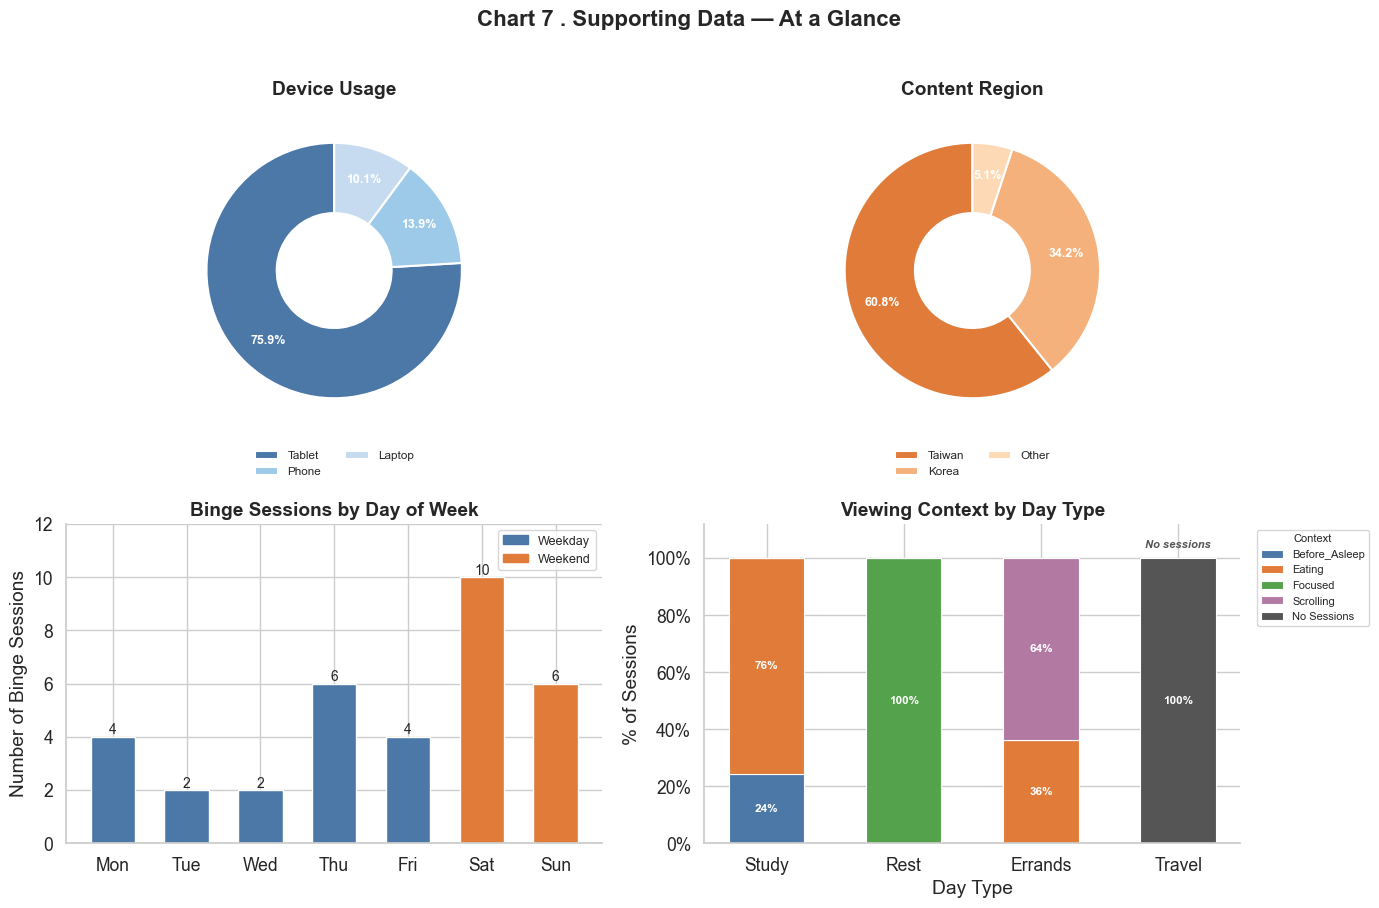

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Chart 7 . Supporting Data — At a Glance", fontsize=16, fontweight="bold", y=1.01)

# ── 1: Device usage ───────────────────────────────────────────────────────────
ax1 = axes[0, 0]
device_counts = (
    df[df["Device"] != "None"]
    .groupby("Device").size()
    .sort_values(ascending=False)
)

wedge_props = dict(width=0.55, edgecolor="white", linewidth=1.5)
ax1.pie(
    device_counts.values,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops=wedge_props,
    colors=["#4c78a8", "#9ecae9", "#c6dbef",
            "#6baed6", "#2171b5"][:len(device_counts)],
    textprops=dict(fontsize=9, color="white", fontweight="bold")
)

# Legend outside
ax1.legend(
    device_counts.index,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=8.5,
    frameon=False
)
ax1.set_title("Device Usage", fontweight="bold", pad=12)

# ── 2: Region distribution ────────────────────────────────────────────────────
ax2 = axes[0, 1]
region_counts = (
    df[df["Region"] != "None"]
    .groupby("Region").size()
    .sort_values(ascending=False)
)

# Merge small regions into "Other" to avoid clutter
threshold = region_counts.sum() * 0.05  # regions < 5% → Other
major = region_counts[region_counts >= threshold]
other = region_counts[region_counts < threshold].sum()
if other > 0:
    major["Other"] = other

wedge_props2 = dict(width=0.55, edgecolor="white", linewidth=1.5)
ax2.pie(
    major.values,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops=wedge_props2,
    colors=["#e07b39", "#f5b17b", "#fdd9b5",
            "#d94701", "#fd8d3c", "#888888"][:len(major)],
    textprops=dict(fontsize=9, color="white", fontweight="bold")
)

ax2.legend(
    major.index,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=8.5,
    frameon=False
)
ax2.set_title("Content Region", fontweight="bold", pad=12)

# ── 3: Binge sessions by day of week ─────────────────────────────────────────
ax3 = axes[1, 0]
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
dow_short  = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

binge_dow = (
    df[df["Binge_Session"]]
    .groupby("DayOfWeek").size()
    .reindex(dow_order, fill_value=0)
)
bar_colors = ["#4c78a8"] * 5 + ["#e07b39"] * 2  # weekday/weekend
ax3.bar(range(7), binge_dow.values, color=bar_colors,
        edgecolor="white", width=0.6)
ax3.set_xticks(range(7))
ax3.set_xticklabels(dow_short)
ax3.set_title("Binge Sessions by Day of Week", fontweight="bold")
ax3.set_ylabel("Number of Binge Sessions")
ax3.set_ylim(0, binge_dow.max() + 2)
for i, val in enumerate(binge_dow.values):
    if val > 0:
        ax3.text(i, val + 0.1, str(val), ha="center", fontsize=10)

weekend_patch = mpatches.Patch(color="#e07b39", label="Weekend")
weekday_patch = mpatches.Patch(color="#4c78a8", label="Weekday")
ax3.legend(handles=[weekday_patch, weekend_patch], fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

# ── 4: Viewing context by day type ───────────────────────────────────────────
ax4 = axes[1, 1]

ctx_day = (
    df[(df["Context"] != "None") & (df["Duration_Mins"] > 0)]
    .groupby(["Day_Type", "Context"])
    .size()
    .reset_index(name="Count")
)

all_contexts = sorted([c for c in df["Context"].unique()
                       if c != "None" and c != "No Sessions"])

ctx_rows = []
for day in day_order:
    sub = ctx_day[ctx_day["Day_Type"] == day]
    total = sub["Count"].sum()
    row = {"Day_Type": day}
    for ctx in all_contexts:
        count = sub[sub["Context"] == ctx]["Count"].sum()
        row[ctx] = (count / total * 100) if total > 0 else 0
    row["No Sessions"] = 100 if total == 0 else 0
    ctx_rows.append(row)

ctx_pct = pd.DataFrame(ctx_rows).set_index("Day_Type").fillna(0)
ctx_pct = ctx_pct.reindex(day_order).fillna(0)

# Columns: real contexts first, No Sessions last
cols = all_contexts + ["No Sessions"]
ctx_pct = ctx_pct[cols]

# One colour per context, No Sessions = dark charcoal
ctx_color_map = {
    "Before_Asleep": "#4c78a8",
    "Eating":        "#e07b39",
    "Focused":       "#54a24b",
    "Scrolling":     "#b279a2",
    "No Sessions":   "#555555"
}

bottom = [0] * len(day_order)
x_pos  = list(range(len(day_order)))

for col in cols:
    values = ctx_pct[col].values
    color  = ctx_color_map.get(col, "#888888")
    ax4.bar(x_pos, values, bottom=bottom,
            color=color, label=col, width=0.55,
            edgecolor="white", linewidth=0.8)
    for j, (val, bot) in enumerate(zip(values, bottom)):
        if val > 12:
            ax4.text(x_pos[j], bot + val / 2, f"{val:.0f}%",
                     ha="center", va="center",
                     fontsize=8.5, color="white", fontweight="bold")
    bottom = [b + v for b, v in zip(bottom, values)]

# Annotate Travel above the bar — no overlap, clearly readable
travel_idx = day_order.index("Travel")
ax4.text(travel_idx, 103,
         "No sessions",
         ha="center", va="bottom",
         fontsize=8, color="#555555",
         fontweight="bold", style="italic")

ax4.set_title("Viewing Context by Day Type", fontweight="bold")
ax4.set_xlabel("Day Type")
ax4.set_ylabel("% of Sessions")
ax4.set_xticks(x_pos)
ax4.set_xticklabels(day_order, rotation=0)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
ax4.set_ylim(0, 112)
ax4.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
           title="Context", title_fontsize=8)
ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart7_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

**Supporting patterns:**
- **Device** — most viewing happens on [Tablet], suggesting
  deliberate seated viewing rather than opportunistic mobile consumption.
- **Region** — [Taiwan] and [Korea] dominates, consistent with the Romance-heavy
  genre profile.
- **Binge days by Day of Week** cluster on [weekends], suggesting decompression
  follows a weekly rhythm rather than being purely fatigue-triggered.
- **Viewing Context by Day Type** — reveals how attention quality 
  shifts across day types. On Study days, viewing is split between Eating (76%) 
  and Before_Asleep (24%), confirming TV functions as background activity rather 
  than deliberate leisure. On Rest days, 100% of sessions are Focused — the only 
  day type where I give full attention to what I watch as entertainment. Errands days show a mix 
  of Scrolling (64%) and Eating (36%), suggesting fragmented opportunistic 
  viewing. Travel days record no sessions at all, indicating that physical exhaustion leads to zero viewing.  

---
## Conclusions

This notebook has argued one claim through six charts :

> **When fatigued, I default to Romance content. When rested, I choose Crime/Thriller. Fatigue does not simply increase viewing — it redirects it toward comfort.**

| Chart | Finding | Role |
|-------|---------|------|
| 1 · Genre × Day Type | Romance dominates on cognitively loaded days | Setup |
| 2 · Calendar Heatmap | Viewing clusters in time; binge sessions follow grey periods | Setup |
| 3 · Fatigue × Duration | U-shaped pattern; extreme fatigue produces outlier binges | Argument |
| 4 · Genre × Fatigue | **Romance share rises with fatigue; Crime drops** | Core claim |
| 5 · Context × Genre | Romance = passive/multitasked; Crime = focused only | Reinforcement |
| 6 · Study × Viewing | Comfort viewing is decompression, not time-filling | Complication |

**Graphical principles applied** (MacKinley 1986 / Cleveland & McGill 1983):
- *Position* (scatter, heatmap axes) for quantitative relationships
- *Length* (bar charts) over angle for proportional comparisons
- *Colour hue* (orange/blue) as a consistent genre identity across all charts
- *Colour saturation* (heatmap) for session frequency encoding

---

*Notebook for the Information Visualization Early Exam — University of Bologna, May 21 2026.*
